# Evaluación de alucinaciones en dominios críticos

## Más allá de la similitud superficial

**Presentación — 10 minutos**

---

*Basado en:*
- Gao et al. (2024). *Retrieval-Augmented Generation for Large Language Models: A Survey.* arXiv:2312.10997
- Magesh et al. (2025). *Hallucination-Free? Assessing the Reliability of Leading AI Legal Research Tools.* Journal of Empirical Legal Studies, 22(2), 216–242

## Agenda

| # | Tema | Tiempo |
|---|---|---|
| 1 | El problema: por qué esto importa | 1 min |
| 2 | Qué es RAG y qué promete | 1,5 min |
| 3 | Por qué ROUGE y BLEU no bastan | 1,5 min |
| 4 | El marco bidimensional de evaluación | 1,5 min |
| 5 | Evidencia empírica | 1,5 min |
| 6 | Implementación del protocolo | 2,5 min |
| 7 | Conclusiones | 0,5 min |

> **La tesis:** en medicina y derecho, una respuesta que *suena* bien y una respuesta que *es* bien
> son cosas distintas. Las métricas actuales solo miden la primera.

## 1. El problema

Un abogado en Nueva York fue sancionado por presentar ante un tribunal casos **inventados por
ChatGPT**. No fue un incidente aislado: se han documentado varios episodios similares.

### Por qué los dominios críticos son distintos

En una tarea general, un error se corrige y ya. En derecho o medicina:

- El costo del error es **asimétrico**: una cita equivocada puede costar un caso o un paciente.
- El error es **difícil de detectar**: verificar exige leer las fuentes citadas y evaluar su autoridad.
- Existe un **deber profesional** de supervisión. Si el profesional debe verificar cada afirmación,
  la ganancia de eficiencia que promete la IA se evapora.

### La pregunta de la investigación

> Los proveedores afirman que RAG *elimina* las alucinaciones.
> **¿Es cierto, y cómo lo medimos de forma que el número signifique algo?**

## 2. Qué es RAG

**Retrieval-Augmented Generation:** en lugar de que el modelo responda de memoria, primero
**busca documentos** en una base de conocimiento y responde a partir de ellos.

La diferencia clave: pasar de un examen **a libro cerrado** a uno **a libro abierto**.

```
Consulta  →  RECUPERACIÓN  →  documentos  →  GENERACIÓN  →  respuesta
             (buscar en la BD)               (LLM + documentos)
```

### Los tres paradigmas (Gao et al., 2024)

| Paradigma | Qué hace | Limitación |
|---|---|---|
| **Naive RAG** | Indexar → recuperar → generar | Recupera pasajes irrelevantes |
| **Advanced RAG** | Optimiza antes (reescritura de consulta) y después (reordenamiento) | Sigue siendo una cadena fija |
| **Modular RAG** | Módulos intercambiables: búsqueda, memoria, enrutamiento, flujos iterativos | Mayor complejidad |

**Punto importante:** cada subpaso —el *embedding*, la búsqueda, cuántos documentos se traen,
el filtrado— es una decisión de diseño que puede introducir errores.

## 3. La promesa comercial

Los proveedores de investigación jurídica han sido enfáticos:

- Un directivo de Thomson Reuters afirmó que RAG reduce las alucinaciones **casi a cero**.
- LexisNexis promocionó **citas jurídicas libres de alucinación** vinculadas a la fuente.
- Casetext sostuvo que su producto **no inventa hechos**.

### El problema de fondo

Ninguna de esas afirmaciones venía acompañada de **evidencia empírica**. Y algo peor:

> El término *alucinación* **no estaba definido** en los materiales de marketing,
> y las propias empresas lo usaban con significados distintos entre sí.

Una empresa lo entendía como *inventarse un caso que no existe*. Otra, como *sonar plausible y ser
falso*. LexisNexis podía cumplir su promesa en el sentido más estrecho —enlazar a documentos
reales— aunque esos documentos no sustentaran la afirmación.

**Sin una definición precisa, la métrica no significa nada.**

## 4. Por qué ROUGE y BLEU no bastan

Las métricas estándar de generación de texto comparan el **solapamiento léxico** con una referencia.

- **BLEU** mide precisión: ¿lo que dije aparecía en la referencia?
- **ROUGE** mide recall: ¿dije lo que había que decir?
- **ROUGE-L** usa la subsecuencia común más larga, así que tolera cambios de orden.

### Su punto ciego

Ambas **cuentan palabras, no verifican hechos**. Y en un dominio crítico eso las rompe:

| Situación | Lo que ve ROUGE | La realidad |
|---|---|---|
| Cita un caso **anulado** | Palabras correctas → puntaje alto | La respuesta es jurídicamente falsa |
| Cita la jurisdicción equivocada | Vocabulario idéntico | La norma no aplica |
| Invierte el fallo del tribunal | Cambian dos palabras | El sentido es el opuesto |
| Explica bien con sinónimos | Poco solapamiento → puntaje bajo | La respuesta es correcta |

> Una respuesta puede tener **alto solapamiento léxico y ser jurídicamente catastrófica**.
> Lo vamos a demostrar en la demo con un caso real.

## 5. La propuesta: descomponer en dos dimensiones

Magesh et al. proponen dejar de tratar la alucinación como una etiqueta binaria y
descomponerla en **dos ejes independientes**:

### Eje 1 — Corrección *(correctness)*
¿La respuesta es **factualmente cierta** y pertinente?
→ `Correcta` · `Incorrecta` · `Negativa (refusal)`

### Eje 2 — Anclaje *(groundedness)*
¿Las afirmaciones están **respaldadas por las fuentes citadas**?
→ `Anclada` · `Mal anclada` · `Sin anclaje`

---

**Por qué separarlos:** una respuesta puede ser **correcta pero mal anclada**. Ocurre cuando la
recuperación falla, el modelo acierta por su cuenta, y **cita una fuente que no dice eso**.
Eso engaña al usuario, porque la cita le da confianza injustificada.

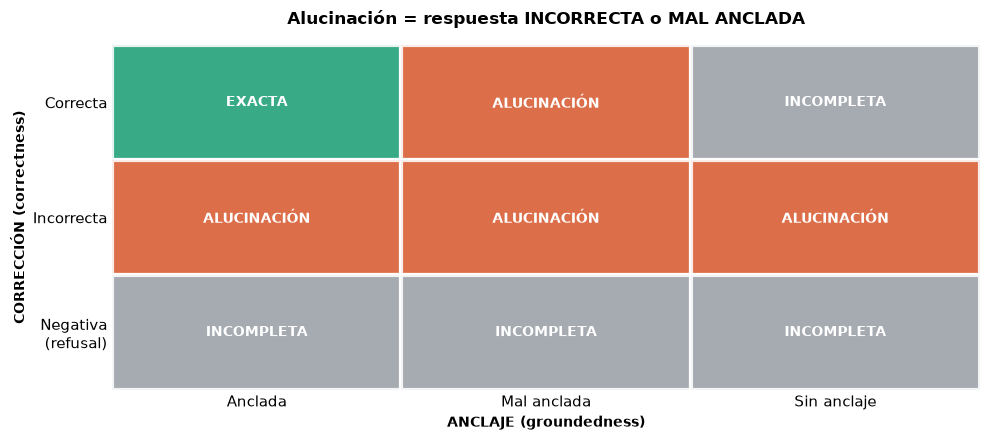

In [1]:
# ── Figura 1: la matriz de clasificación ──
import matplotlib.pyplot as plt

VERDE, NARANJA, GRIS, MORADO = "#1D9E75", "#D85A30", "#9AA0A6", "#7F77DD"

fig, ax = plt.subplots(figsize=(10, 4.5))
filas = ["Correcta", "Incorrecta", "Negativa\n(refusal)"]
cols  = ["Anclada", "Mal anclada", "Sin anclaje"]
etiq = [["EXACTA", "ALUCINACIÓN", "INCOMPLETA"],
        ["ALUCINACIÓN", "ALUCINACIÓN", "ALUCINACIÓN"],
        ["INCOMPLETA", "INCOMPLETA", "INCOMPLETA"]]
color = {"EXACTA": VERDE, "ALUCINACIÓN": NARANJA, "INCOMPLETA": GRIS}

for i in range(3):
    for j in range(3):
        ax.add_patch(plt.Rectangle((j, 2 - i), 1, 1, facecolor=color[etiq[i][j]],
                                   edgecolor="white", linewidth=3, alpha=0.88))
        ax.text(j + 0.5, 2 - i + 0.5, etiq[i][j], ha="center", va="center",
                color="white", fontweight="bold", fontsize=10)

ax.set_xlim(0, 3); ax.set_ylim(0, 3)
ax.set_xticks([0.5, 1.5, 2.5]); ax.set_xticklabels(cols, fontsize=11)
ax.set_yticks([2.5, 1.5, 0.5]); ax.set_yticklabels(filas, fontsize=11)
ax.set_xlabel("ANCLAJE (groundedness)", fontweight="bold")
ax.set_ylabel("CORRECCIÓN (correctness)", fontweight="bold")
ax.set_title("Alucinación = respuesta INCORRECTA o MAL ANCLADA", fontweight="bold", pad=15)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout(); plt.show()

## 6. Definiciones operativas

A partir de los dos ejes se derivan tres etiquetas de alto nivel:

| Etiqueta | Definición | Por qué |
|---|---|---|
| **Alucinación** | Incorrecta **o** mal anclada | El sistema afirma algo falso, o afirma falsamente que una fuente lo respalda |
| **Exacta** | Correcta **y** anclada | Es el único caso plenamente útil |
| **Incompleta** | Negativa **o** sin anclaje | No miente, pero no entrega lo que el profesional necesita |

### Dos decisiones de diseño que vale la pena defender

**1. Una respuesta sin citas es *incompleta*, no alucinación.**
No hace ninguna afirmación falsa sobre sus fuentes; simplemente no da el respaldo que se requiere.

**2. Este *anclaje* no es el de la literatura de computación.**
Allí anclaje significa *adherirse al documento recuperado*, sin importar si ese documento es
aplicable. Aquí se evalúan **recuperador y generador juntos**: si el sistema cita fielmente un
precedente anulado, técnicamente está anclado, pero **jurídicamente está mal anclado**.

> Ese matiz es justo el que hace que la métrica sea *útil en el dominio* y no solo *consistente*.

## 7. Evidencia empírica

**Diseño del estudio:** 202 consultas jurídicas, **preregistradas** antes de ejecutarlas para evitar
sesgo de selección. Evaluación **manual** por expertos en derecho.

Cuatro categorías de consulta: investigación general, específicas de jurisdicción o tiempo,
de premisa falsa, y de recuperación factual.

**Fiabilidad entre evaluadores:** kappa de Cohen de 0,77 y 85,4 % de acuerdo. Las etiquetas están
bien definidas.

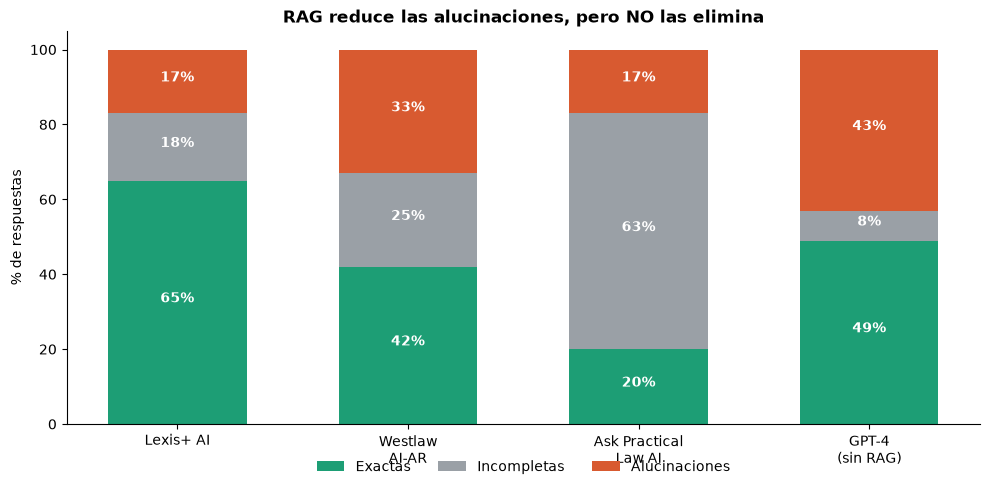

In [2]:
# ── Figura 2: resultados por sistema ──
import numpy as np

sistemas      = ["Lexis+ AI", "Westlaw\nAI-AR", "Ask Practical\nLaw AI", "GPT-4\n(sin RAG)"]
exactas       = [65, 42, 20, 49]
incompletas   = [18, 25, 63,  8]
alucinaciones = [17, 33, 17, 43]

x = np.arange(len(sistemas))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x, exactas, 0.6, label="Exactas", color=VERDE)
ax.bar(x, incompletas, 0.6, bottom=exactas, label="Incompletas", color=GRIS)
ax.bar(x, alucinaciones, 0.6, bottom=np.array(exactas) + np.array(incompletas),
       label="Alucinaciones", color=NARANJA)

for i in range(len(x)):
    ax.text(i, exactas[i] / 2, f"{exactas[i]}%", ha="center",
            color="white", fontweight="bold")
    ax.text(i, exactas[i] + incompletas[i] / 2, f"{incompletas[i]}%", ha="center",
            color="white", fontweight="bold")
    ax.text(i, exactas[i] + incompletas[i] + alucinaciones[i] / 2, f"{alucinaciones[i]}%",
            ha="center", color="white", fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(sistemas)
ax.set_ylabel("% de respuestas"); ax.set_ylim(0, 105)
ax.set_title("RAG reduce las alucinaciones, pero NO las elimina", fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=3, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Cómo leer estos números

**RAG sí ayuda.** GPT-4 sin recuperación alucina en el 43 % de los casos; las herramientas
especializadas bajan a entre 17 % y 33 %.

**Pero la promesa de "casi cero" es falsa.** Una de cada seis respuestas de la mejor herramienta
contiene información falsa o engañosa.

**Cada sistema falla distinto:**

- **Westlaw** alucina el doble que las demás. Una causa concreta: genera las respuestas más largas
  (unas 350 palabras frente a 219 y 175). Más proposiciones falsables → más probabilidad de que al
  menos una sea falsa, y más trabajo de verificación.
- **Ask Practical Law** casi no responde: el 63 % de sus respuestas son incompletas. Su universo de
  búsqueda está limitado a guías internas, no a la ley primaria.
- **Ser cauteloso no es ser confiable.** Westlaw y Practical Law responden menos que GPT-4, pero las
  respuestas que sí dan no son significativamente más confiables.

## 8. Por qué fallan: tipología de errores

| Causa | Qué ocurre |
|---|---|
| **Recuperación ingenua** | No encuentra la fuente adecuada, porque recuperar exige razonamiento jurídico que la similitud de texto no captura |
| **Autoridad inaplicable** | Cita jurisdicción equivocada, norma derogada o precedente anulado |
| **Error de razonamiento** | Recupera el texto correcto pero malinterpreta el fallo, o confunde el alegato de una parte con la decisión del juez |
| **Sicofancia** | Acepta como cierta una premisa falsa introducida por el usuario |

> **Aporte nuevo:** la evaluación general de RAG asume que los documentos recuperados son
> verdaderos y aplicables. **En derecho esa suposición es falsa**: la ley cambia, varía por
> jurisdicción, y decidir si un documento es vinculante exige razonamiento no trivial.

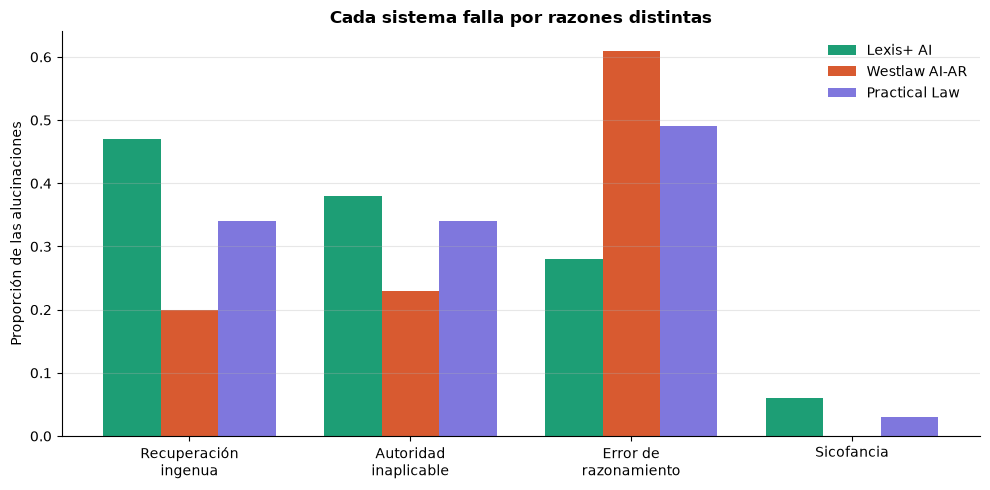

Lexis falla sobre todo al RECUPERAR.
Westlaw falla sobre todo al RAZONAR sobre lo que ya recuperó.
=> Arreglar el recuperador no arregla a Westlaw. El diagnóstico dirige la solución.


In [3]:
# ── Figura 3: prevalencia de cada causa ──
causas  = ["Recuperación\ningenua", "Autoridad\ninaplicable", "Error de\nrazonamiento", "Sicofancia"]
lexis   = [0.47, 0.38, 0.28, 0.06]
westlaw = [0.20, 0.23, 0.61, 0.00]
pract   = [0.34, 0.34, 0.49, 0.03]

x = np.arange(len(causas)); w = 0.26
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, lexis,   w, label="Lexis+ AI",     color=VERDE)
ax.bar(x,     westlaw, w, label="Westlaw AI-AR", color=NARANJA)
ax.bar(x + w, pract,   w, label="Practical Law", color=MORADO)

ax.set_xticks(x); ax.set_xticklabels(causas)
ax.set_ylabel("Proporción de las alucinaciones")
ax.set_title("Cada sistema falla por razones distintas", fontweight="bold")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("Lexis falla sobre todo al RECUPERAR.")
print("Westlaw falla sobre todo al RAZONAR sobre lo que ya recuperó.")
print("=> Arreglar el recuperador no arregla a Westlaw. El diagnóstico dirige la solución.")

# Parte II — Implementación del protocolo

## Qué construimos

Un evaluador que **audita metadatos de dominio**, no solo texto. La diferencia con ROUGE:

| | ROUGE-L | Nuestro evaluador |
|---|---|---|
| Qué compara | Palabras contra una referencia | Citas contra metadatos de la base de conocimiento |
| Detecta un precedente anulado | ❌ | ✅ `is_still_good_law` |
| Detecta jurisdicción equivocada | ❌ | ✅ `jurisdiction` |
| Detecta una cita inventada | ❌ | ✅ la cita no existe en la base |
| Detecta un fallo invertido | ❌ | ✅ `actual_holding` |

**La clave del diseño:** cada documento de la base lleva metadatos de **vigencia** y **jurisdicción**.
Sin ellos es imposible distinguir una cita válida de una cita muerta.

## Estructuras de datos

In [4]:
import re
from dataclasses import dataclass
from enum import Enum
from typing import List, Dict

In [5]:
class CorrectnessStatus(Enum):
    CORRECT = "Correct"
    INCORRECT = "Incorrect"
    REFUSAL = "Refusal"


class GroundednessStatus(Enum):
    GROUNDED = "Grounded"
    MISGROUNDED = "Misgrounded"
    UNGROUNDED = "Ungrounded"
    NOT_APPLICABLE = "N/A"


class DomainErrorType(Enum):
    NONE = "None"
    INAPPLICABLE_AUTHORITY_OVERRULED = "Inapplicable Authority (Overruled/Derogated)"
    MISUNDERSTANDING_HOLDING = "Misunderstanding Holding / Medical Result"
    HIERARCHY_VIOLATION = "Hierarchy / Jurisdiction Violation"
    SUPERFICIAL_RETRIEVAL_FLAW = "Superficial Semantic Retrieval Flaw"
    FABRICATED_CITATION = "Fabricated / Non-existent Citation"


@dataclass
class CitationMetadata:
    citation_id: str
    source_title: str
    is_still_good_law: bool   # False si el caso fue anulado / la guía ya no está vigente
    jurisdiction: str
    actual_holding: str


@dataclass
class RAGResponse:
    query: str
    generated_text: str
    cited_ids: List[str]


@dataclass
class EvaluationReport:
    superficial_rouge_score: float
    correctness: CorrectnessStatus
    groundedness: GroundednessStatus
    is_hallucination: bool
    is_accurate: bool
    domain_errors: List[DomainErrorType]

print("Estructuras definidas: los dos ejes del marco + la tipología de errores de dominio")

Estructuras definidas: los dos ejes del marco + la tipología de errores de dominio


## El evaluador

Una sola clase con tres bloques:

**①  Corrección** — correcta, incorrecta o negativa.
**②  Anclaje** — recorre cada cita y **audita sus metadatos** contra la base de conocimiento.
**③  Clasificación** — aplica las definiciones del marco y calcula ROUGE-L para contrastar.

> El bloque ② es el corazón del aporte: ahí es donde se detecta lo que ninguna métrica de texto ve.

In [6]:
class DomainRAGEvaluator:
    def __init__(self, knowledge_base_metadata: Dict[str, CitationMetadata]):
        self.kb = knowledge_base_metadata

    @staticmethod
    def _tokenize(text: str) -> List[str]:
        return re.findall(r"\w+", text.lower())

    # ---------- Metrica superficial: ROUGE-L (F1) con la subsecuencia comun mas larga ----------
    def compute_superficial_rouge_l(self, candidate: str, reference: str) -> float:
        c, r = self._tokenize(candidate), self._tokenize(reference)
        if not c or not r:
            return 0.0

        # LCS por programacion dinamica
        dp = [[0] * (len(r) + 1) for _ in range(len(c) + 1)]
        for i in range(1, len(c) + 1):
            for j in range(1, len(r) + 1):
                if c[i - 1] == r[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1] + 1
                else:
                    dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
        lcs = dp[-1][-1]

        if lcs == 0:
            return 0.0
        precision, recall = lcs / len(c), lcs / len(r)
        return 2 * precision * recall / (precision + recall)

    # ---------- Evaluacion de dominio ----------
    def evaluate_response(
        self,
        rag_response: RAGResponse,
        ground_truth_fact: str,
        target_jurisdiction: str,
        is_negated_holding: bool = False,
        is_refusal: bool = False,
    ) -> EvaluationReport:
        domain_errors: List[DomainErrorType] = []

        def add_error(err: DomainErrorType):
            if err not in domain_errors:
                domain_errors.append(err)

        # (1) CORRECCION factual (simplificacion: se recibe como bandera)
        if is_refusal:
            correctness = CorrectnessStatus.REFUSAL
        elif is_negated_holding:
            correctness = CorrectnessStatus.INCORRECT
            add_error(DomainErrorType.MISUNDERSTANDING_HOLDING)
        else:
            correctness = CorrectnessStatus.CORRECT

        # (2) ANCLAJE: se audita SIEMPRE que haya citas  <-- el corazon del protocolo
        if correctness == CorrectnessStatus.REFUSAL:
            groundedness = GroundednessStatus.NOT_APPLICABLE
        elif not rag_response.cited_ids:
            groundedness = GroundednessStatus.UNGROUNDED
        else:
            misgrounded = False
            for cite_id in rag_response.cited_ids:
                meta = self.kb.get(cite_id)
                if meta is None:                       # la cita no existe en la base
                    misgrounded = True
                    add_error(DomainErrorType.FABRICATED_CITATION)
                    continue
                if not meta.is_still_good_law:         # precedente anulado / guia derogada
                    misgrounded = True
                    add_error(DomainErrorType.INAPPLICABLE_AUTHORITY_OVERRULED)
                if meta.jurisdiction != target_jurisdiction:   # jurisdiccion equivocada
                    misgrounded = True
                    add_error(DomainErrorType.HIERARCHY_VIOLATION)
            groundedness = (GroundednessStatus.MISGROUNDED if misgrounded
                            else GroundednessStatus.GROUNDED)

        # (3) CLASIFICACION final segun el marco de Magesh et al.
        is_hallucination = (correctness == CorrectnessStatus.INCORRECT
                            or groundedness == GroundednessStatus.MISGROUNDED)
        is_accurate = (correctness == CorrectnessStatus.CORRECT
                       and groundedness == GroundednessStatus.GROUNDED)

        # (4) Metrica superficial, solo para contrastarla con el veredicto de dominio
        rouge = self.compute_superficial_rouge_l(rag_response.generated_text, ground_truth_fact)

        return EvaluationReport(
            superficial_rouge_score=round(rouge, 3),
            correctness=correctness,
            groundedness=groundedness,
            is_hallucination=is_hallucination,
            is_accurate=is_accurate,
            domain_errors=domain_errors or [DomainErrorType.NONE],
        )


print("Evaluador listo. Fijate en el bloque (2): ahi se auditan vigencia y jurisdiccion.")

Evaluador listo. Fijate en el bloque (2): ahi se auditan vigencia y jurisdiccion.


## Demostración: el caso *Casey* / *Dobbs*

**El escenario.** Se pregunta qué estándar aplica a las regulaciones del aborto según la
Constitución de EE. UU.

El sistema RAG responde: *el estándar de carga indebida, establecido en Planned Parenthood v. Casey*,
y **cita ese caso, que es real**.

### Por qué es una alucinación

*Casey* fue **anulado en 2022** por *Dobbs v. Jackson Women's Health Organization*. El estándar
vigente es otro.

> Es el caso perfecto: la cita **existe**, el texto **suena correcto**, y el solapamiento léxico con
> la verdad es **razonable**. Ninguna métrica superficial lo detecta.

In [8]:
# --- EJEMPLO DE PRUEBA DEL PROTOCOLO ---
# Base de conocimiento con metadatos de vigencia (ej. Caso Dobbs / Casey)
kb = {
    "case_101": CitationMetadata(
        citation_id="case_101",
        source_title="Planned Parenthood v. Casey",
        is_still_good_law=False,  # Anulado por Dobbs v. Jackson
        jurisdiction="US_Supreme_Court",
        actual_holding="Establecía el estándar de carga indebida (Undue burden).",
    )
}

evaluator = DomainRAGEvaluator(knowledge_base_metadata=kb)

# Respuesta generada por RAG que cita un caso real pero ANULADO
rag_output = RAGResponse(
    query="¿Qué estándar se aplica a las regulaciones del aborto según la Constitución de EE. UU.?",
    generated_text="El estándar aplicable es el de carga indebida según lo establecido en el caso Planned Parenthood v. Casey.",
    cited_ids=["case_101"],
)

referencia_correcta = ("El estándar de carga indebida de Casey fue anulado en Dobbs v. Jackson; "
                       "actualmente aplica el juicio de base racional.")

report = evaluator.evaluate_response(
    rag_response=rag_output,
    ground_truth_fact=referencia_correcta,
    target_jurisdiction="US_Supreme_Court",
    is_negated_holding=True,
)

print("=== RESULTADOS DE EVALUACIÓN DE DOMINIO ===")
print(f"Puntuación ROUGE-L: {report.superficial_rouge_score} (parece aceptable por solapamiento léxico)")
print(f"Estado de Corrección: {report.correctness.value}")
print(f"Estado de Anclaje: {report.groundedness.value}")
print(f"¿Es Alucinación de Dominio?: {report.is_hallucination} (detecta el error crítico que ROUGE ignora)")
print(f"¿Es Respuesta Exacta?: {report.is_accurate}")
print(f"Tipos de Errores Detectados: {[e.value for e in report.domain_errors]}")

=== RESULTADOS DE EVALUACIÓN DE DOMINIO ===
Puntuación ROUGE-L: 0.368 (parece aceptable por solapamiento léxico)
Estado de Corrección: Incorrect
Estado de Anclaje: Misgrounded
¿Es Alucinación de Dominio?: True (detecta el error crítico que ROUGE ignora)
¿Es Respuesta Exacta?: False
Tipos de Errores Detectados: ['Misunderstanding Holding / Medical Result', 'Inapplicable Authority (Overruled/Derogated)']


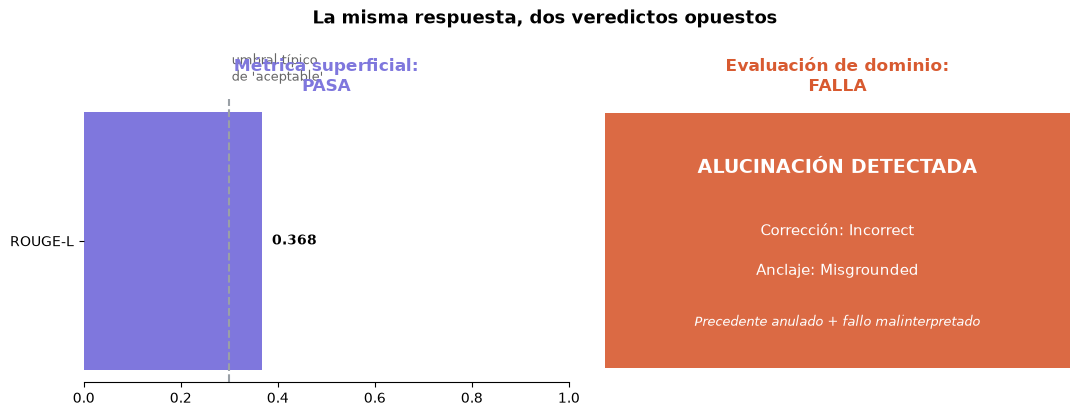

In [9]:
# ── Figura 4: los dos veredictos, lado a lado ──
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))

a1.barh(["ROUGE-L"], [report.superficial_rouge_score], color=MORADO, height=0.45)
a1.axvline(0.3, color=GRIS, ls="--", lw=1.5)
a1.text(0.305, 0.28, "umbral típico\nde 'aceptable'", fontsize=9, color="#666")
a1.set_xlim(0, 1)
a1.text(report.superficial_rouge_score + 0.02, 0, f"{report.superficial_rouge_score}",
        va="center", fontweight="bold")
a1.set_title("Métrica superficial:\nPASA", color=MORADO, fontweight="bold")
a1.spines[["top", "right", "left"]].set_visible(False)

a2.axis("off")
a2.add_patch(plt.Rectangle((0.02, 0.05), 0.96, 0.9, facecolor=NARANJA, alpha=0.9))
a2.text(0.5, 0.74, "ALUCINACIÓN DETECTADA", ha="center", color="white",
        fontweight="bold", fontsize=14)
a2.text(0.5, 0.52, f"Corrección: {report.correctness.value}", ha="center",
        color="white", fontsize=11)
a2.text(0.5, 0.38, f"Anclaje: {report.groundedness.value}", ha="center",
        color="white", fontsize=11)
a2.text(0.5, 0.20, "Precedente anulado + fallo malinterpretado", ha="center",
        color="white", fontsize=9, style="italic")
a2.set_title("Evaluación de dominio:\nFALLA", color=NARANJA, fontweight="bold")

fig.suptitle("La misma respuesta, dos veredictos opuestos", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

### Qué demuestra la demo

**ROUGE-L dio 0,368.** En muchos trabajos ese valor se reporta como un resultado aceptable.

**El evaluador de dominio detectó dos errores distintos:**

1. `MISUNDERSTANDING_HOLDING` — el fallo citado ya no es el criterio vigente.
2. `INAPPLICABLE_AUTHORITY_OVERRULED` — la autoridad fue anulada.

> **El punto de todo el trabajo:** si hubiéramos evaluado este sistema únicamente con métricas
> superficiales, lo habríamos aprobado. Un abogado que confiara en esa respuesta citaría ante un
> tribunal un precedente anulado hace tres años.

## Limitaciones honestas

**De nuestra implementación:**

- La corrección factual entra como **bandera manual** (`is_negated_holding`). Automatizarla exigiría
  comparar contra el fallo real, que es precisamente la parte difícil.
- La jurisdicción se compara por **igualdad estricta**. La jerarquía real es un grafo: un tribunal
  superior vincula a los inferiores de su circuito.
- La base de conocimiento es un **ejemplo mínimo** de un solo caso.

**Del estudio original:**

- Evaluación **manual y costosa**: no se puede dejar que las herramientas se autoevalúen, porque
  la fidelidad a la autoridad es justo lo que está en duda.
- Es una **foto en el tiempo**: los sistemas cambian, y son cerrados, sin acceso programático.
- El anclaje existe en un **espectro**: una cita anulada puede seguir siendo útil como punto de
  partida de una investigación, aunque aquí se codifique como mal anclada.

## Conclusiones

**1. RAG reduce las alucinaciones, pero no las elimina.**
De 43 % sin recuperación a entre 17 % y 33 % con ella. La promesa de "cero" no se sostiene.

**2. Las métricas superficiales no sirven para dominios críticos.**
Lo demostramos: ROUGE-L aprobó una respuesta que cita un precedente anulado.

**3. La evaluación útil exige descomponer y auditar metadatos.**
Separar **corrección** de **anclaje**, y verificar **vigencia** y **jurisdicción** de cada cita.

**4. El diagnóstico dirige la solución.**
Lexis falla al recuperar; Westlaw falla al razonar. Mejorar el recuperador no arregla a Westlaw.

---

### Implicaciones

- **Para el profesional:** el deber de competencia y supervisión exige verificar cada cita. Estas
  herramientas sirven como **primer paso** de la investigación, no como palabra final.
- **Para el proveedor:** afirmar "libre de alucinaciones" sin evidencia expone a responsabilidad
  por publicidad engañosa.
- **Para el campo:** hacen falta *benchmarks* públicos y auditorías de terceros. Las evaluaciones
  hechas por el propio vendedor no bastan.

## Referencias

**Fuentes principales**

- Gao, Y., Xiong, Y., Gao, X., et al. (2024). *Retrieval-Augmented Generation for Large Language
  Models: A Survey.* arXiv:2312.10997
  https://doi.org/10.48550/arXiv.2312.10997

- Magesh, V., Surani, F., Dahl, M., Suzgun, M., Manning, C. D., & Ho, D. E. (2025).
  *Hallucination-Free? Assessing the Reliability of Leading AI Legal Research Tools.*
  Journal of Empirical Legal Studies, 22(2), 216–242.
  https://doi.org/10.1111/jels.12413 · preprint: arXiv:2405.20362

**Complementarias citadas en la presentación**

- Dahl, M., Magesh, V., Suzgun, M., & Ho, D. E. (2024). *Large Legal Fictions: Profiling Legal
  Hallucinations in Large Language Models.* Journal of Legal Analysis, 16(1), 64–93.
- Lewis, P., Perez, E., Piktus, A., et al. (2020). *Retrieval-Augmented Generation for
  Knowledge-Intensive NLP Tasks.* NeurIPS 33.
- Barnett, S., et al. (2024). *Seven Failure Points When Engineering a Retrieval Augmented
  Generation System.* arXiv:2401.05856

---

### Cómo exportar esto como diapositivas

```bash
jupyter nbconvert presentacion_alucinaciones.ipynb --to slides --post serve
```

Cada celda ya trae la metadata `slideshow` configurada.

**¿Preguntas?**